[INFO] Loaded 107 batches from /home/silas/co-scientist-project/runs/2026/2/0-9_scale/15(2_3)
[INFO] Using rubric key: rubric/sample_mean_all
[INFO] Loaded 107 batches from /home/silas/co-scientist-project/runs/2026/2/0-9_scale/15(None)
[INFO] Using rubric key: rubric/sample_mean_all

=== RUN A ===
     final: 0.7388
      best: 0.7659
      mean: 0.6990
       auc: 74.0894

=== RUN B ===
     final: 0.7430
      best: 0.7599
      mean: 0.6969
       auc: 73.8667

=== B - A (raw rubric) ===
final diff: 0.0042
mean diff : -0.0021
best diff : 0.0246


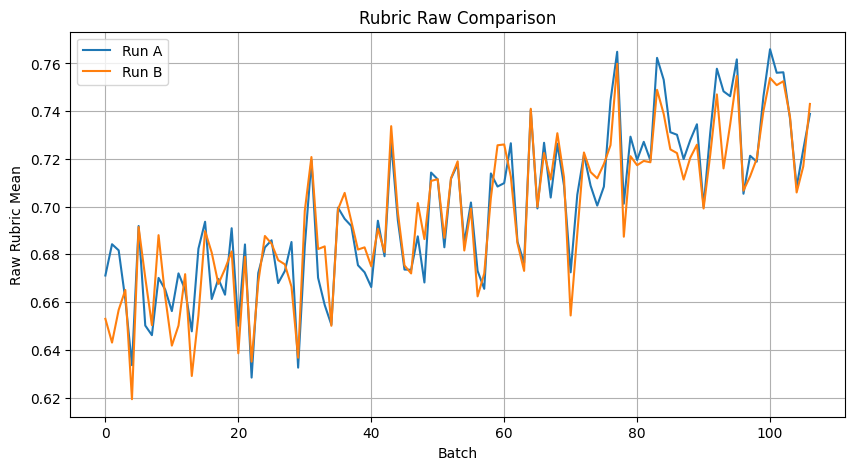

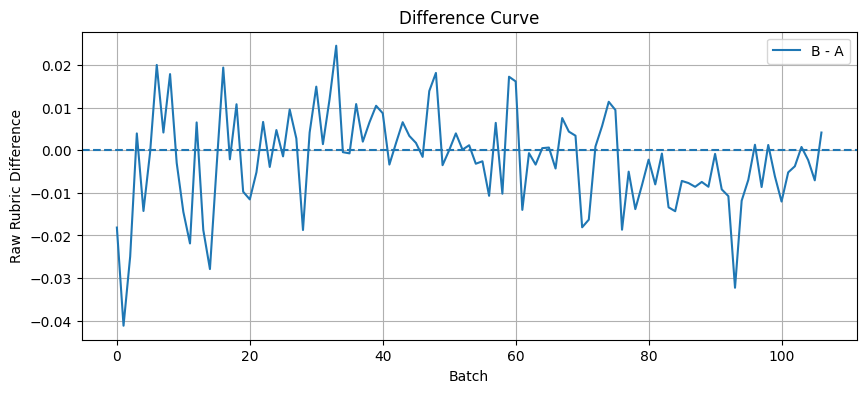

In [38]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 👉 改这里
# =========================
RUN_A_PATH = "/home/silas/co-scientist-project/runs/2026/2/0-9_scale/15(2_3)"
RUN_B_PATH = "/home/silas/co-scientist-project/runs/2026/2/0-9_scale/15(None)"

POSSIBLE_KEYS = [
    "rubric_raw/sample_mean_all",
    "rubric/sample_mean_all",
]

def extract_rubric_value(record):
    for key in POSSIBLE_KEYS:
        if key in record:
            return record[key], key
    return None, None

def load_rubric_curve(log_dir):
    summary_path = os.path.join(log_dir, "train", "batch_summary.jsonl")
    if not os.path.exists(summary_path):
        raise FileNotFoundError(f"Cannot find {summary_path}")

    curve = []
    used_key = None

    with open(summary_path, "r") as f:
        for line in f:
            record = json.loads(line)
            value, key = extract_rubric_value(record)
            if value is not None:
                curve.append(value)
                if used_key is None:
                    used_key = key

    if not curve:
        raise ValueError(f"No rubric key found in {summary_path}")

    print(f"[INFO] Loaded {len(curve)} batches from {log_dir}")
    print(f"[INFO] Using rubric key: {used_key}")
    return np.array(curve)

def summarize(curve):
    return {
        "final": float(curve[-1]),
        "best": float(np.max(curve)),
        "mean": float(np.mean(curve)),
        "auc": float(np.trapezoid(curve)),  # ← 改这里
    }


# =========================
# 加载数据
# =========================
curve_a = load_rubric_curve(RUN_A_PATH)
curve_b = load_rubric_curve(RUN_B_PATH)

min_len = min(len(curve_a), len(curve_b))
curve_a = curve_a[:min_len]
curve_b = curve_b[:min_len]

summary_a = summarize(curve_a)
summary_b = summarize(curve_b)

# =========================
# 打印统计
# =========================
print("\n=== RUN A ===")
for k, v in summary_a.items():
    print(f"{k:>10}: {v:.4f}")

print("\n=== RUN B ===")
for k, v in summary_b.items():
    print(f"{k:>10}: {v:.4f}")

diff = curve_b - curve_a

print("\n=== B - A (raw rubric) ===")
print(f"final diff: {diff[-1]:.4f}")
print(f"mean diff : {np.mean(diff):.4f}")
print(f"best diff : {np.max(diff):.4f}")

# =========================
# 画曲线
# =========================
plt.figure(figsize=(10, 5))
plt.plot(curve_a, label="Run A")
plt.plot(curve_b, label="Run B")
plt.xlabel("Batch")
plt.ylabel("Raw Rubric Mean")
plt.title("Rubric Raw Comparison")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 画差值曲线
# =========================
plt.figure(figsize=(10, 4))
plt.plot(diff, label="B - A")
plt.axhline(0, linestyle="--")
plt.xlabel("Batch")
plt.ylabel("Raw Rubric Difference")
plt.title("Difference Curve")
plt.legend()
plt.grid(True)
plt.show()
